## Computer Vision

Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and $k$NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
Single X_train[i] shape: (28, 28)
Single X_test[i] shape: (28, 28)
y_train shape: (60000,)
y_test shape: (10000,)
k=1, accuracy=0.9691
k=3, accuracy=0.9705
k=5, accuracy=0.9688
k=7, accuracy=0.9694
k=9, accuracy=0.9659

Best k = 3 with accuracy = 0.9705

Final Accuracy: 0.9705


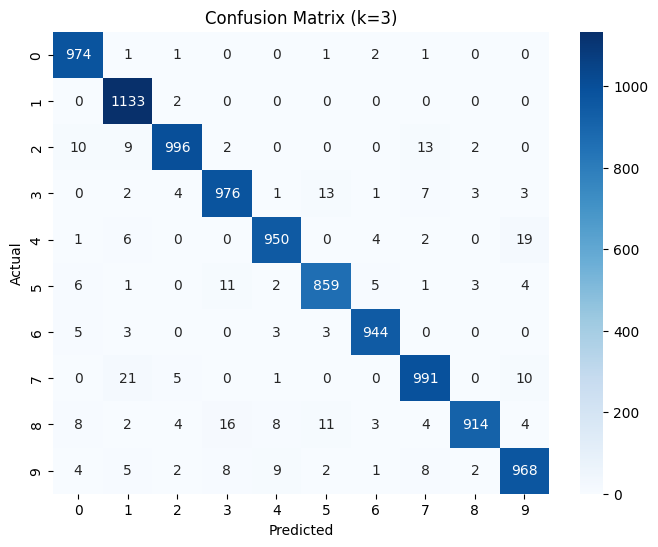


Most common correct classifications (diagonal largest counts): [1 2 7 3 0]
Most common misclassifications (off-diagonal):

=== How to represent a color photo numerically ===

A color photo of size H×W uses RGB channels.
Each pixel = (R, G, B) with values 0–255.

Thus the image is a 3D tensor:  (H, W, 3)

Example: a 1920×1080 color photo is shaped (1080, 1920, 3).

To convert to tabular data:
1. Flatten the (H, W, 3) array into a vector of length 3HW.
2. Each pixel contributes 3 features (R, G, B).
3. This produces a single long feature row suitable for ML models.



In [1]:
###############################################
# MNIST KNN PIPELINE — COMPLETE ONE-CELL SOLUTION
###############################################

import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# ------------------------------------------------------
# 1. Load data
# ------------------------------------------------------
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# ------------------------------------------------------
# 2. Print shapes
# ------------------------------------------------------
print("X_train shape:", train_X.shape)   # (#samples, 28, 28)
print("X_test shape:",  test_X.shape)    # (#samples, 28, 28)
print("Single X_train[i] shape:", train_X[0].shape)  # (28,28)
print("Single X_test[i] shape:",  test_X[0].shape)   # (28,28)
print("y_train shape:", train_y.shape)   # (#samples,)
print("y_test shape:",  test_y.shape)    # (#samples,)

# ------------------------------------------------------
# 3. Reshape into vectors of length 784
# ------------------------------------------------------
n_train = train_X.shape[0]
n_test  = test_X.shape[0]

X_train = train_X.reshape(n_train, 784)
X_test  = test_X.reshape(n_test, 784)

# Normalize pixel values (optional, but improves accuracy)
X_train = X_train / 255.0
X_test  = X_test / 255.0

# ------------------------------------------------------
# 4. Search for optimal k
# ------------------------------------------------------
accuracies = {}
for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, train_y)
    preds = knn.predict(X_test)
    acc = accuracy_score(test_y, preds)
    accuracies[k] = acc
    print(f"k={k}, accuracy={acc:.4f}")

best_k = max(accuracies, key=accuracies.get)
print("\nBest k =", best_k, "with accuracy =", accuracies[best_k])

# ------------------------------------------------------
# 5. Fit final model & evaluate
# ------------------------------------------------------
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, train_y)
pred_test = model.predict(X_test)
final_acc = accuracy_score(test_y, pred_test)
print("\nFinal Accuracy:", final_acc)

# ------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------
cm = confusion_matrix(test_y, pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")
plt.title(f"Confusion Matrix (k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Interpretation of errors
most_confused_pairs = np.unravel_index(np.argsort(cm, axis=None)[::-1], cm.shape)
print("\nMost common correct classifications (diagonal largest counts):", most_confused_pairs[0][:5])
print("Most common misclassifications (off-diagonal):")
for i in range(10):
    a, b = most_confused_pairs[0][i], most_confused_pairs[1][i]
    if a != b:
        print(f"Actual {a} → Predicted {b} with {cm[a,b]} occurrences")
        break

# ------------------------------------------------------
# 7. Explanation: representing a color photo as tabular data
# ------------------------------------------------------
print("\n=== How to represent a color photo numerically ===")
print("""
A color photo of size H×W uses RGB channels.
Each pixel = (R, G, B) with values 0–255.

Thus the image is a 3D tensor:  (H, W, 3)

Example: a 1920×1080 color photo is shaped (1080, 1920, 3).

To convert to tabular data:
1. Flatten the (H, W, 3) array into a vector of length 3HW.
2. Each pixel contributes 3 features (R, G, B).
3. This produces a single long feature row suitable for ML models.
""")
